# Independent Component Analysis (ICA)

## ICA

Implementing Independent Component Analysis (ICA) from scratch using only `NumPy`. Using the `FastICA` algorithm as reference.

* Testing the implementation using test signals (e.g. sinewave, squarewave,etc) and plotting the signal waves before and after ICA.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from typing import Optional, Callable, Tuple

In [ ]:
class ICA:
    """
    Independent Component Analysis (ICA) using the FastICA algorithm.

    ICA is a computational method for separating a multivariate signal into
    additive subcomponents, assuming that the subcomponents are statistically
    independent and non-Gaussian.
    """

    def __init__(
        self,
        n_components: Optional[int] = None,
        max_iter: int = 200,
        tol: float = 1e-4,
        random_state: Optional[int] = None,
        whiten: bool = True
    ):
        self.n_components = n_components
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state
        self.whiten = whiten
        self.W_ = None
        self.mean_ = None
        self.whitening_matrix_ = None
        self.dewhitening_matrix_ = None
        self.n_iter_ = 0

    def _center_data(self, X: np.ndarray) -> np.ndarray:
        """Center the data by subtracting the mean."""
        self.mean_ = np.mean(X, axis=1, keepdims=True)
        return X - self.mean_

    def _whiten_data(self, X: np.ndarray) -> np.ndarray:
        """Whiten the data using eigenvalue decomposition."""
        cov = np.cov(X)
        eigenvalues, eigenvectors = np.linalg.eigh(cov)
        # Avoid division by zero
        eigenvalues = np.where(eigenvalues <= 0, 1e-8, eigenvalues)
        d = np.diag(1.0 / np.sqrt(eigenvalues))
        self.whitening_matrix_ = d @ eigenvectors.T
        self.dewhitening_matrix_ = np.linalg.inv(self.whitening_matrix_)
        return self.whitening_matrix_ @ X

    def _symmetric_decorrelation(self, W: np.ndarray) -> np.ndarray:
        """Apply symmetric decorrelation to the unmixing matrix."""
        # W @ W.T should be identity after decorrelation
        cov_W = W @ W.T
        eigenvalues, eigenvectors = np.linalg.eigh(cov_W)
        # Avoid division by zero
        eigenvalues = np.where(eigenvalues <= 0, 1e-8, eigenvalues)
        d = np.diag(1.0 / np.sqrt(eigenvalues))
        return eigenvectors @ d @ eigenvectors.T @ W

    def fit(self, X: np.ndarray) -> 'ICA':
        """
        Fit the ICA model to the data.

        Parameters:
        X : array-like, shape (n_features, n_samples)
            Training data where each column is a sample.
        """
        if self.random_state is not None:
            np.random.seed(self.random_state)

        X = self._center_data(X)
        if self.whiten:
            X = self._whiten_data(X)

        n_features = X.shape[0]
        n_components = self.n_components or n_features

        # Initialize unmixing matrix
        self.W_ = np.random.randn(n_components, n_features)

        for self.n_iter_ in range(self.max_iter):
            # Compute whitened sources
            S = self.W_ @ X

            # Nonlinearity: g(u) = tanh(u), g'(u) = 1 - tanh(u)^2
            g = np.tanh(S)
            g_prime = 1 - g**2

            # Update rule
            W_new = (g @ X.T) / X.shape[1] - np.diag(np.mean(g_prime, axis=1)) @ self.W_

            # Symmetric decorrelation
            W_new = self._symmetric_decorrelation(W_new)

            # Check convergence
            change = np.max(np.abs(W_new - self.W_))
            self.W_ = W_new
            if change < self.tol:
                break

        return self

    def transform(self, X: np.ndarray) -> np.ndarray:
        """
        Apply the unmixing matrix to the data.

        Parameters:
        X : array-like, shape (n_features, n_samples)
            Data to transform.

        Returns:
        S : array-like, shape (n_components, n_samples)
            Estimated independent components.
        """
        X_centered = X - self.mean_
        if self.whiten:
            X_centered = self.whitening_matrix_ @ X_centered
        return self.W_ @ X_centered

    def inverse_transform(self, S: np.ndarray) -> np.ndarray:
        """
        Transform the sources back to the mixed data space.

        Parameters:
        S : array-like, shape (n_components, n_samples)
            Independent components.

        Returns:
        X : array-like, shape (n_features, n_samples)
            Reconstructed mixed signals.
        """
        X = np.linalg.pinv(self.W_) @ S
        if self.whiten:
            X = self.dewhitening_matrix_ @ X
        return X + self.mean_


In [ ]:
def generate_test_signals(n_samples: int = 2000, random_state: int = 42) -> Tuple[np.ndarray, np.ndarray]:
    """
    Generate test signals for ICA demonstration.

    Parameters:
    n_samples : int
        Number of time points.
    random_state : int
        Seed for reproducibility.

    Returns:
    X_mixed : array-like, shape (n_sources, n_samples)
        Mixed observed signals.
    sources : array-like, shape (n_sources, n_samples)
        Original independent sources.
    """
    np.random.seed(random_state)

    t = np.linspace(0, 8 * np.pi, n_samples)

    # Generate independent sources
    s1 = np.sin(t)  # Sine wave
    s2 = np.sign(np.sin(3 * t))  # Square wave
    s3 = (2 / np.pi) * np.arcsin(np.sin(t))  # Sawtooth approximation

    sources = np.vstack([s1, s2, s3])

    # Mixing matrix (random but fixed for reproducibility)
    mixing_matrix = np.array([[1, 0.5, 0.3],
                              [0.5, 1, 0.2],
                              [0.3, 0.2, 1]])

    # Mix the sources
    X_mixed = mixing_matrix @ sources

    return X_mixed, sources


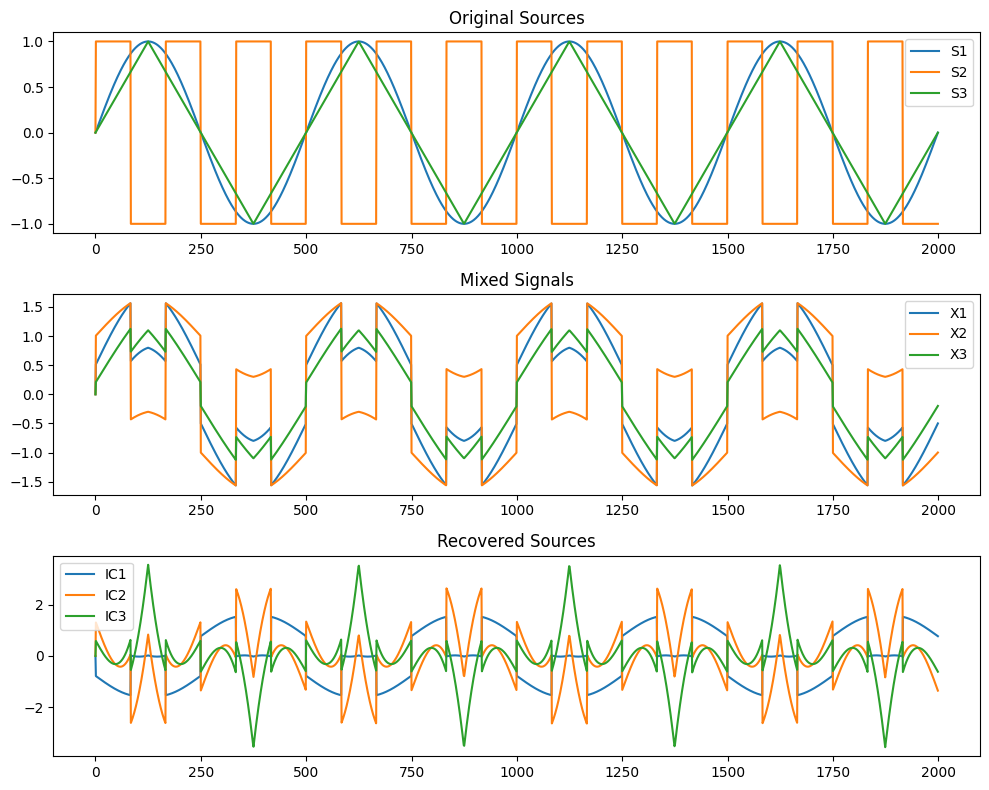

In [ ]:
import matplotlib.pyplot as plt

X, S = generate_test_signals()
ica = ICA(n_components=3, random_state=42)
ica.fit(X)
S_est = ica.transform(X)

fig, axes = plt.subplots(3, 1, figsize=(10, 8))
axes[0].plot(S.T); axes[0].set_title('Original Sources'); axes[0].legend(['S1', 'S2', 'S3'])
axes[1].plot(X.T); axes[1].set_title('Mixed Signals'); axes[1].legend(['X1', 'X2', 'X3'])
axes[2].plot(S_est.T); axes[2].set_title('Recovered Sources'); axes[2].legend(['IC1', 'IC2', 'IC3'])
plt.tight_layout()
plt.show()


## ICA on IRIS Dataset

* Using the ICA class on the `IRIS` dataset.
* Visualizing independent input features using scatter plots.



In [ ]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

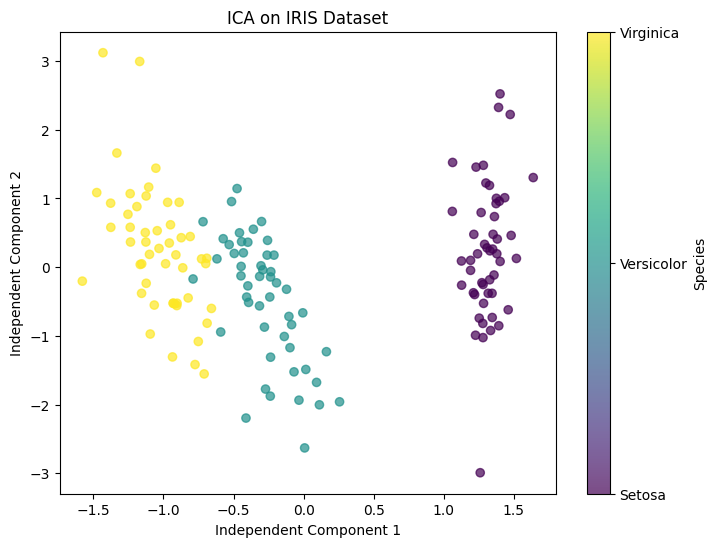

In [ ]:
iris = load_iris()
X = iris.data.T  # Shape (n_features=4, n_samples=150)
y = iris.target

# Standardize (optional, but helps convergence)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X.T).T  # Back to (features, samples)

# Fit ICA (reduce to 2 components for visualization)
ica = ICA(n_components=2, random_state=42, whiten=True)
ica.fit(X_scaled)
S = ica.transform(X_scaled)

# Scatter plot of IC1 vs IC2
plt.figure(figsize=(8, 6))
scatter = plt.scatter(S[0], S[1], c=y, cmap='viridis', alpha=0.7)
plt.xlabel('Independent Component 1')
plt.ylabel('Independent Component 2')
plt.title('ICA on IRIS Dataset')
plt.colorbar(scatter, ticks=[0, 1, 2], label='Species', format=plt.FuncFormatter(lambda x, pos: ['Setosa', 'Versicolor', 'Virginica'][int(x)]))
plt.show()